This tutorial shows how to use the reding functions of the hfradar package

In [1]:
# System modules

import os
import glob
import sys

# Import scientific modules

import numpy as np
import xarray as xr

# Graphical packages

import matplotlib.pyplot as plt

# Add the path to the package if it is not already in PYTHONPATH

sys.path.append(os.sep.join(os.getcwd().split(os.sep)[:-1]) + os.sep)
from hfradar import read_ctf, read_lluv, read_ruv, read_cross_spectra
#from hfradar import plot_radial

# Each time a module is modified it is releaded

%load_ext autoreload
%autoreload 2

# Inline ploting

%matplotlib inline

# Read CODAR radial files (.ruv)

In [2]:
# Search a .ruv file from the sample data

filename = glob.glob('data/*.ruv')[0]

# Read it and return an Xarray Dataset

data = read_ruv(filename)

Explore the content of the file

In [3]:
data

<xarray.Dataset> Size: 796kB
Dimensions:  (time: 1, range: 69, bearing: 72)
Coordinates:
  * time     (time) datetime64[s] 8B 2026-06-05T11:00:00
  * range    (range) float64 552B 0.0 1.664 3.328 4.993 ... 109.8 111.5 113.2
  * bearing  (bearing) float64 576B 3.0 8.0 13.0 18.0 ... 348.0 353.0 358.0
Data variables: (12/20)
    lond     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    latd     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    velu     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    velv     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    vflg     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    espc     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    ...       ...
    ydst     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    rnge     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    bear     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    velo     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    head     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
    sprc     (time, range, bearing) float64 40kB nan nan nan nan ... nan nan nan
Attributes: (12/60)
    CTF:                           1.00
    FileType:                      LLUV rdls RadialMap
    LLUVSpec:                      1.51 2021 07 01
    UUID:                          1AF0EF80-0544-4F9B-8A83-EDDCE3409788
    Manufacturer:                  CODAR Ocean Sensors. SeaSonde
    Site:                          GNST 
    ...                            ...
    MergeVectorLocation:           False
    MergeSources:                  7
    ProcessedTimeStamp:            2026 06 05 11 40 09
    ProcessingTool:                ['LLUVMusic 13.6.1', 'LLUVMerger 3.2.2', '...
    lluv_subtype:                  rdls
    filename:                      RDLm_GNST_2026_06_05_1100.ruv

Plot radial velocities

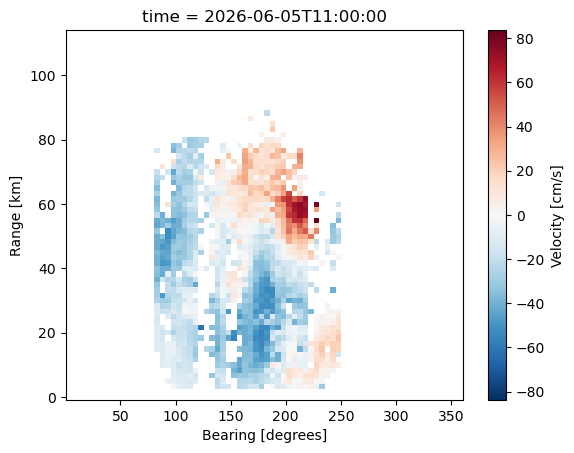

In [4]:
data['velo'].plot()

# Read CSS files

In [5]:
# Search a .ruv file from the sample data

filename = glob.glob('data/*.csr')[0]

# Read it and return a dictionary

data = read_cross_spectra(filename)

Explore the contents of the file

In [6]:
# Print the header

print('Header')
print('-' * 6)
for key in data['header'].keys():
    print(key + ':', data['header'][key])


Header
------
sign_nFileVersion: 1.04
sign_nFileType: CSSY
sign_nOwner: GNST
sign_szFileName: SeaSonde Shortened CrossSpectra
sign_szOwnerName: CODAR Ocean Sensors, Ltd
sign_szComment: 
srcn_szSourceFile: CSS_GNST_24_06_07_1430.cs
mcda_nDateTime: 3800615400
mcda_datetime: 2024-06-07 14:30:00+00:00
dbrf_fReceiverPowerLossDB: 0.0
nCsFileVersion: 6
nDateTime: 3800615400
datetime: 2024-06-07 14:30:00+00:00
nV1Extent: 7679
nCsKind: 2
nV2Extent: 7673
nSiteCodeName: GNST
nV3Extent: 7665
nCoverMinutes: 15
bDeletedSource: 0
bOverrideSrcInfo: 0
fStartFreqMHz: 13.545034408569336
fRepFreqHz: 2.0
fBandwidthKHz: 90.06869506835938
bSweepUp: 0
nDopplerCells: 512
nRangeCells: 69
nFirstRangeCell: 1
fRangeCellDistKm: 1.6642433404922485
nV4Extent: 7617
nOutputInterval: 4
nCreateTypeCode: SSAQ
nCreatorVersion: 12.0
nActiveChannels: 3
nSpectraChannels: 3
nActiveChanBits: 7
nV5Extent: 7589


Self Spectra Power

Some Antenna3 amplitude values may be negative to indicate noise or interference at those doppler bins. These negative values should be absolute before use.

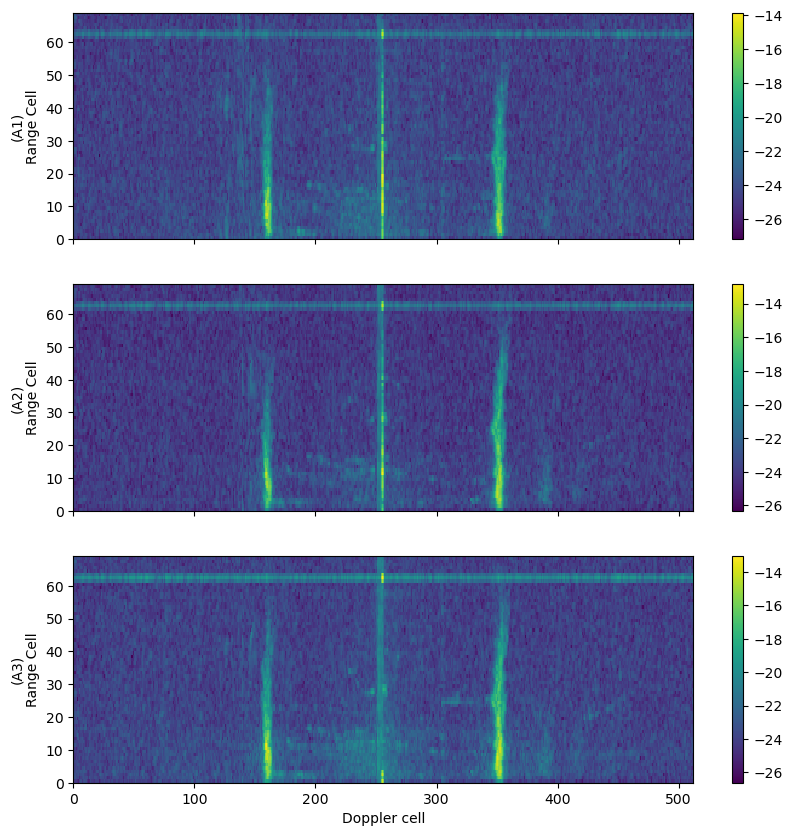

In [7]:
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 10))

for i in np.arange(3):
    
    key = 'antenna' + str(i + 1) + '_self'
    title = '(A' + str(i+1) + ')'
    
    spec = np.ma.array(data = np.abs(data['data'][key]), 
                       mask = np.zeros(data['data'][key].shape, dtype=bool))
    spec.mask[spec.data <=0] = True
    
    fig.colorbar(ax[i].pcolormesh(np.log(spec)), ax=ax[i])
    ax[i].set_ylabel(title + '\n' + 'Range Cell')
    if i == 2:
        ax[i].set_xlabel('Doppler cell')


In [8]:
for key in data['data'].keys():
    print(key, data['data'][key].dtype)

antenna1_self float32
antenna2_self float32
antenna3_self float32
cross_12 complex128
cross_13 complex128
cross_23 complex128
quality float32


In [9]:
for key in data['v6_blocks'].keys():
    print(key, data['v6_blocks'][key])

TIME {'nTimeMark': 0, 'nYear': 2024, 'nMonth': 6, 'nDay': 7, 'nHour': 14, 'nMinute': 30, 'fSeconds': 0.0, 'fCoverageSeconds': 3.5064123699384e-310, 'fHoursFromUTC': 0.0}
ZONE {'value': 'Atlantic/Reykjavik'}
LOCA {'fLatitude': 1.34386e-319, 'fLongitude': 1.7272341829017006e-77, 'fAltitudeMeters': 0.0}
ANTI {'raw': b'\x00\x00\x00\x00\x00\x00\x00\x00'}
RCVI {'nReceiverModel': 0, 'nRxAntennaModel': 0, 'fReferenceGainDB': 34.2, 'szFirmware': ''}
GLRM {'nMethod': 2, 'nVersion': 1, 'nPointsRemoved': 0, 'nTimesRemoved': 0, 'nSegmentsRemoved': 0, 'fPointPowerThreshold': 15.0, 'fRangePowerThreshold': 10.0, 'fRangeBinThreshold': 0.5, 'bRemoveDC': False}
SUPI {'nMethod': 1, 'nVersion': 1, 'nMode': 4, 'nDebugMode': 0, 'nDopplerSuppressed': 14, 'fPowerThreshold': 6.0, 'fRangeBinThreshold': 33.0, 'nRangeBanding': 8, 'nDopplerDetectionSmoothing': 5}
SUPM {'fSuppressionVoltageSquared': array([[1.0000001, 1.0000001, 1.0000001, ..., 1.0000001, 1.0000001,
        1.       ],
       [1.0000001, 1.0000001, 

In [10]:
for key in data.keys():
    print(key)

file_type
header
v6_blocks
data
